# BGL Log Anomaly Detection: One-Class SVM Pipeline
### (OC-SVM Replacement for Deep SVDD)

### Pipeline 1 — One-Class SVM
**Stage 1 — OC-SVM (One-Class Support Vector Machine)**
- Trained exclusively on normal logs (50 % of all normal logs)
- Learns a decision boundary in a kernel-induced feature space that encloses normal log embeddings
- Flags any test log whose embedding falls outside the boundary as anomalous

**Design Choices**
1. **RBF kernel** — maps sentence embeddings into a high-dimensional space where a separating hyperplane is easier to find
2. **ν (nu) parameter** — upper bound on the fraction of training outliers and lower bound on the fraction of support vectors; tuned on a validation set
3. **Validation-set threshold calibration** — decision scores on held-out normal logs are used to select the optimal threshold
4. **Precision-recall curve threshold selection** — F-beta (β=0.5) maximisation to explicitly weight precision over recall
5. **AUC-ROC** — area under the Receiver Operating Characteristic curve reported alongside traditional metrics

**Evaluation**
- Traditional binary metrics: Accuracy, Precision, Recall, F1-Score
- AUC-ROC

## Dataset
- Source          : BGL 2k structured log dataset
- Label convention: `'-'` = Normal, any other label = Anomalous
- OC-SVM train    : 50 % of all normal logs
- Validation set  : 200 held-out normal logs (threshold calibration only — never seen during training)
- Test set        : drawn from remaining held-out normal logs and anomalous logs


In [1]:
# =============================================================================
# CELL 1 — PACKAGE INSTALLATION
#
# Install all third-party dependencies required by this notebook.
# Run this cell once before executing Cell 2.
# torch is NOT required for OC-SVM; scikit-learn provides the model.
# =============================================================================

import subprocess
import sys


def install_packages(packages):
    """
    Install a list of pip packages programmatically.

    This avoids the need to run pip in a separate terminal and ensures
    the correct Python environment (the kernel's interpreter) is used.

    Args:
        packages: List of pip-installable package specifiers.
    """
    for pkg in packages:
        print(f"Installing: {pkg}")
        result = subprocess.run(
            [sys.executable, "-m", "pip", "install", pkg, "-q"],
            capture_output=True,
            text=True,
        )
        if result.returncode != 0:
            print(f"  WARNING: installation may have failed for {pkg}")
            print(f"  stderr: {result.stderr[:200]}")
        else:
            print(f"  OK")


REQUIRED_PACKAGES = [
    # Data science core
    "pandas",
    "numpy",
    "scikit-learn",
    "matplotlib",
    "seaborn",
    # Embedding model
    "sentence-transformers",
]

install_packages(REQUIRED_PACKAGES)
print("\nAll packages installed successfully.")


Installing: pandas
  OK
Installing: numpy
  OK
Installing: scikit-learn
  OK
Installing: matplotlib
  OK
Installing: seaborn
  OK
Installing: sentence-transformers
  OK

All packages installed successfully.


C:\Users\Abhishek Mulay\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  Embedding model   : all-MiniLM-L6-v2
  OC-SVM kernel     : rbf
  OC-SVM nu         : 0.05
  OC-SVM gamma      : scale
  F-beta            : 0.5
  Train ratio       : 0.5
  Val normal count  : 200
  Test set size     : 825  (800 normal + 25 anomalous)
Loading BGL structured log dataset ...
  Structured log rows : 2000
  Template rows       : 120
  Label distribution  :
-           1857
KERNDTLB      60
KERNSTOR      30
APPSEV        17
KERNMNTF      11
KERNTERM       7
KERNREC        5
APPRES         4
APPREAD        3
APPTO          2
KERNRTSP       2
APPCHILD       1
APPOUT         1
  Normal logs         : 1857
  Anomalous logs      : 143
  Sample log text     : [KERNEL] [INFO] instruction cache parity error corrected | Template: instruction cache parity error corrected
Splitting dataset ...
  OC-SVM training logs      : 928 (normal only)
  Held-out normal logs      : 929
  Validation normal logs    : 200  (threshold calibration)
  Test normal logs          : 729
  Test anomalous l

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6353.23it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Embedding dimension : 384
Encoding OC-SVM training logs ...


Batches: 100%|██████████| 15/15 [00:08<00:00,  1.82it/s]


  Training embeddings shape  : (928, 384)
Encoding validation logs ...


Batches: 100%|██████████| 4/4 [00:02<00:00,  1.63it/s]


  Validation embeddings shape: (200, 384)
Encoding test logs ...


Batches: 100%|██████████| 12/12 [00:06<00:00,  1.96it/s]


  Test embeddings shape      : (754, 384)
Scaling embeddings (StandardScaler fit on training set) ...
  Scaling complete.
Training OC-SVM (kernel=rbf, nu=0.05, gamma=scale) ...
  OC-SVM training complete.
  Number of support vectors : 107
Computing validation-set decision scores for threshold calibration ...
  Validation anomaly score stats (normal logs only):
    Min    : -1.1100
    Median : -0.4877
    Max    : 1.5283

  Threshold selection via F-beta (beta=0.5) on validation PR curve:
    Best threshold (anomaly score) : 0.0463
    At threshold   : Precision=1.000, Recall=1.000, F0.5=1.000

Scoring test logs with OC-SVM ...
  OC-SVM flagged as Anomalous : 71
  OC-SVM flagged as Normal    : 683
Computing evaluation metrics ...

  PIPELINE EVALUATION (OC-SVM)
  Test set size      : 754
    Normal  (neg)    : 729
    Anomalous (pos)  : 25
--------------------------------------------------------------
  TP (caught anomalies) : 24
  TN (correct normals)  : 682
  FP (false alarms)     : 

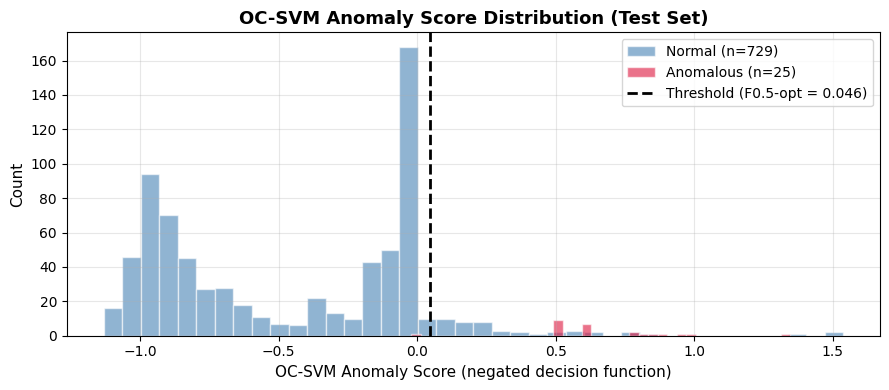

  Saved: ocsvm_score_distribution.png


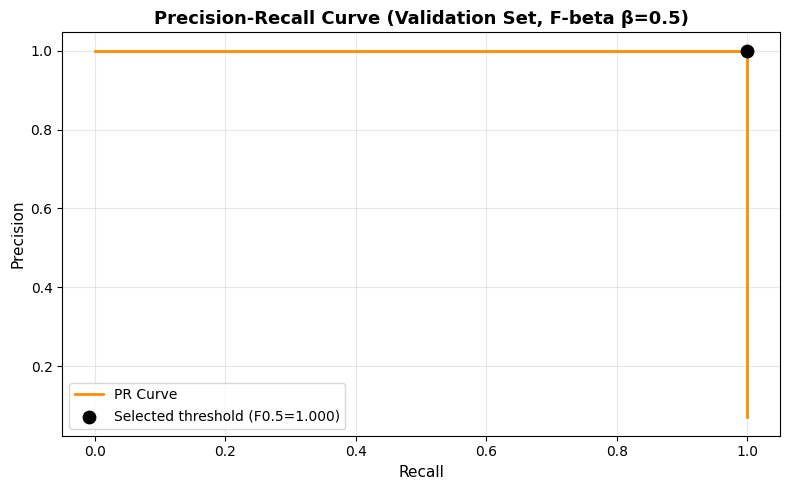

  Saved: ocsvm_pr_curve.png


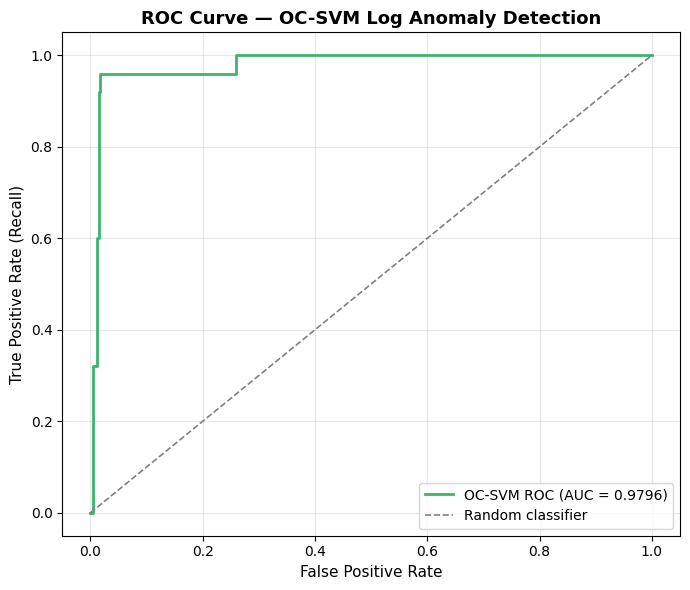

  Saved: ocsvm_roc_curve.png


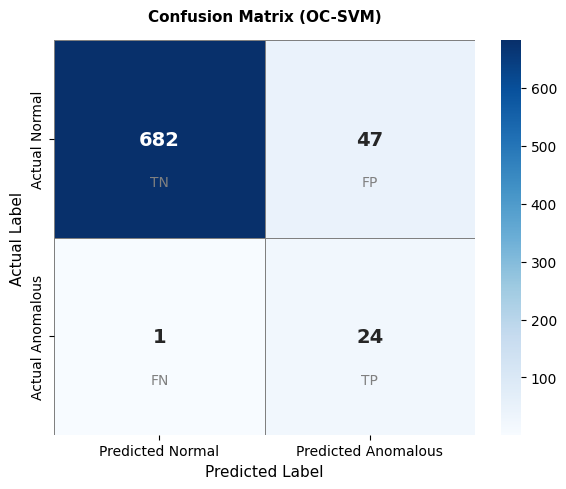

  Saved: ocsvm_confusion_matrix.png


In [2]:
# =============================================================================
# CELL 2 — MAIN PIPELINE  (OC-SVM)
#
# This single cell contains the One-Class SVM pipeline and evaluations.
#
# Sections:
#   1.  Imports and global configuration
#   2.  Data loading and preprocessing
#   3.  Train / validation / test split
#   4.  Sentence embedding
#   5.  OC-SVM training
#   6.  Threshold calibration on validation set (PR-curve, F-beta)
#   7.  OC-SVM anomaly detection on the test set
#   8.  Evaluation: traditional metrics + AUC-ROC
#   9.  Visualisations
# =============================================================================


# ---------------------------------------------------------------------------
# Section 1: Imports and global configuration
# ---------------------------------------------------------------------------

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

warnings.filterwarnings("ignore")

# Reproducibility seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ---------------------------------------------------------------------------
# Pipeline configuration
# ---------------------------------------------------------------------------

# File paths
STRUCTURED_LOG_PATH = "../BGL/BGL_2k.log_structured.csv"
TEMPLATES_PATH = "../BGL/BGL_2k.log_templates.csv"

# Embedding model (384-dimensional output)
EMBED_MODEL_NAME = "all-MiniLM-L6-v2"
EMBED_DIM = 384

# OC-SVM hyper-parameters
# nu  : upper bound on training outlier fraction / lower bound on SV fraction
# gamma : RBF kernel bandwidth ('scale' = 1 / (n_features * X.var()))
OCSVM_NU            = 0.05      # Tighter boundary → fewer false positives
OCSVM_KERNEL        = "rbf"
OCSVM_GAMMA         = "scale"

# Same train / validation / test ratios as the Deep SVDD notebook
OCSVM_TRAIN_RATIO   = 0.50     # Fraction of normal logs used for OC-SVM training
VAL_NORMAL_COUNT    = 200      # Held-out normal logs used only for threshold calibration

# F-beta weight; beta < 1 penalises false positives more than false negatives
FBETA = 0.5                    # beta=0.5 weights precision 2x over recall

# Test set composition (identical to Deep SVDD notebook)
TEST_SET_SIZE        = 825
TEST_NORMAL_COUNT    = 800
TEST_ANOMALOUS_COUNT = 25

print(f"  Embedding model   : {EMBED_MODEL_NAME}")
print(f"  OC-SVM kernel     : {OCSVM_KERNEL}")
print(f"  OC-SVM nu         : {OCSVM_NU}")
print(f"  OC-SVM gamma      : {OCSVM_GAMMA}")
print(f"  F-beta            : {FBETA}")
print(f"  Train ratio       : {OCSVM_TRAIN_RATIO}")
print(f"  Val normal count  : {VAL_NORMAL_COUNT}")
print(f"  Test set size     : {TEST_SET_SIZE}  "
      f"({TEST_NORMAL_COUNT} normal + {TEST_ANOMALOUS_COUNT} anomalous)")


# ---------------------------------------------------------------------------
# Section 2: Data loading and preprocessing
# ---------------------------------------------------------------------------


def build_log_text(row):
    """
    Construct a structured text representation of a single log row.

    Combines the component name, severity level, raw log content, and the
    parsed event template into one string. This enriched representation
    improves embedding quality by exposing both the concrete content and
    the abstract pattern to the sentence transformer.

    Args:
        row: A pandas Series or dict-like object with keys Component,
             Level, Content, and EventTemplate.

    Returns:
        A formatted string of the form:
        "[COMPONENT] [LEVEL] <content> | Template: <template>"
    """
    component = str(row.get("Component", "")).strip()
    level     = str(row.get("Level", "")).strip()
    content   = str(row.get("Content", "")).strip()
    template  = str(row.get("EventTemplate", "")).strip()
    return f"[{component}] [{level}] {content} | Template: {template}"


print("Loading BGL structured log dataset ...")
df_logs      = pd.read_csv(STRUCTURED_LOG_PATH)
df_templates = pd.read_csv(TEMPLATES_PATH)

print(f"  Structured log rows : {len(df_logs)}")
print(f"  Template rows       : {len(df_templates)}")
print(f"  Label distribution  :")
print(df_logs["Label"].value_counts().to_string(header=False))

# Binary labels: '-' is Normal; anything else is Anomalous
df_logs["is_normal"]    = df_logs["Label"] == "-"
df_logs["binary_label"] = df_logs["is_normal"].apply(lambda x: 0 if x else 1)

# Merge templates to enrich log text with the parsed event pattern
df_merged = df_logs.merge(
    df_templates, on="EventId", how="left", suffixes=("", "_template")
)
df_merged["log_text"] = df_merged.apply(build_log_text, axis=1)

n_normal    = df_merged["is_normal"].sum()
n_anomalous = (~df_merged["is_normal"]).sum()
print(f"  Normal logs         : {n_normal}")
print(f"  Anomalous logs      : {n_anomalous}")
print(f"  Sample log text     : {df_merged['log_text'].iloc[0]}")


# ---------------------------------------------------------------------------
# Section 3: Train / validation / test split
#
# Split strategy (identical to Deep SVDD notebook):
#   - OC-SVM training set : 50 % of all normal logs
#   - Validation set      : VAL_NORMAL_COUNT held-out normal logs
#                           (threshold calibration only — never seen during training)
#   - Test set            : remaining held-out normal logs + anomalous logs
# ---------------------------------------------------------------------------

print("Splitting dataset ...")

all_normal    = df_merged[df_merged["is_normal"]].copy()
all_anomalous = df_merged[~df_merged["is_normal"]].copy()

# Shuffle normal logs before splitting for reproducibility
all_normal = all_normal.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

# OC-SVM training set: first 50 % of normal logs
n_ocsvm_train  = int(len(all_normal) * OCSVM_TRAIN_RATIO)
ocsvm_train_df = all_normal.iloc[:n_ocsvm_train].reset_index(drop=True)

# Held-out normal logs: remaining 50 %
held_out_normal_df = all_normal.iloc[n_ocsvm_train:].reset_index(drop=True)

# Validation split: first VAL_NORMAL_COUNT from held-out normals
val_normal_df = held_out_normal_df.iloc[:VAL_NORMAL_COUNT].reset_index(drop=True)

# Test normals: everything after the validation slice
post_val_normal_df = held_out_normal_df.iloc[VAL_NORMAL_COUNT:].reset_index(drop=True)

# Test set: sample TEST_NORMAL_COUNT from post-validation held-out normals
#           and TEST_ANOMALOUS_COUNT from all anomalous logs
test_normal_sample = post_val_normal_df.sample(
    n=min(TEST_NORMAL_COUNT, len(post_val_normal_df)), random_state=RANDOM_SEED
).reset_index(drop=True)
test_anomalous_sample = all_anomalous.sample(
    n=min(TEST_ANOMALOUS_COUNT, len(all_anomalous)), random_state=RANDOM_SEED
).reset_index(drop=True)

df_test = pd.concat(
    [test_normal_sample, test_anomalous_sample], ignore_index=True
)
df_test = df_test.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

print(f"  OC-SVM training logs      : {len(ocsvm_train_df)} (normal only)")
print(f"  Held-out normal logs      : {len(held_out_normal_df)}")
print(f"  Validation normal logs    : {len(val_normal_df)}  (threshold calibration)")
print(f"  Test normal logs          : {len(test_normal_sample)}")
print(f"  Test anomalous logs       : {len(test_anomalous_sample)}")
print(f"  Total test logs           : {len(df_test)}")
print(f"  Test set normal ratio     : "
      f"{len(test_normal_sample) / len(df_test) * 100:.1f} %")
print(f"  Test set anomalous ratio  : "
      f"{len(test_anomalous_sample) / len(df_test) * 100:.1f} %")


# ---------------------------------------------------------------------------
# Section 4: Sentence embedding
# ---------------------------------------------------------------------------

print(f"Loading embedding model '{EMBED_MODEL_NAME}' ...")
embedder         = SentenceTransformer(EMBED_MODEL_NAME)
actual_embed_dim = embedder.get_sentence_embedding_dimension()
print(f"  Embedding dimension : {actual_embed_dim}")
EMBED_DIM = actual_embed_dim

print("Encoding OC-SVM training logs ...")
ocsvm_train_texts      = ocsvm_train_df["log_text"].tolist()
ocsvm_train_embeddings = embedder.encode(
    ocsvm_train_texts, batch_size=64, show_progress_bar=True
)
print(f"  Training embeddings shape  : {ocsvm_train_embeddings.shape}")

print("Encoding validation logs ...")
val_texts      = val_normal_df["log_text"].tolist()
val_embeddings = embedder.encode(
    val_texts, batch_size=64, show_progress_bar=True
)
print(f"  Validation embeddings shape: {val_embeddings.shape}")

print("Encoding test logs ...")
test_texts      = df_test["log_text"].tolist()
test_embeddings = embedder.encode(
    test_texts, batch_size=64, show_progress_bar=True
)
print(f"  Test embeddings shape      : {test_embeddings.shape}")

# Feature scaling — OC-SVM with RBF kernel is sensitive to feature scale.
# Fit scaler on training embeddings only; transform val and test.
print("Scaling embeddings (StandardScaler fit on training set) ...")
scaler = StandardScaler()
ocsvm_train_scaled = scaler.fit_transform(ocsvm_train_embeddings)
val_scaled         = scaler.transform(val_embeddings)
test_scaled        = scaler.transform(test_embeddings)
print("  Scaling complete.")


# ---------------------------------------------------------------------------
# Section 5: OC-SVM training
#
# OneClassSVM learns a decision boundary in the RBF kernel feature space
# that encloses the training (normal) data.  Points outside the boundary
# receive a negative decision score; points inside receive a positive score.
#
# Key hyper-parameters:
#   nu    : controls the trade-off between boundary tightness and training
#           errors; lower nu → tighter boundary → fewer false positives but
#           potentially more missed anomalies.
#   gamma : RBF bandwidth.  "scale" = 1 / (n_features * Var(X)) adapts
#           automatically to the embedding dimensionality.
# ---------------------------------------------------------------------------

print(f"Training OC-SVM (kernel={OCSVM_KERNEL}, nu={OCSVM_NU}, gamma={OCSVM_GAMMA}) ...")
ocsvm_model = OneClassSVM(
    kernel=OCSVM_KERNEL,
    nu=OCSVM_NU,
    gamma=OCSVM_GAMMA,
)
ocsvm_model.fit(ocsvm_train_scaled)
print("  OC-SVM training complete.")
n_svs = ocsvm_model.support_vectors_.shape[0]
print(f"  Number of support vectors : {n_svs}")


# ---------------------------------------------------------------------------
# Section 6: Threshold calibration on validation set
#
# OC-SVM's decision_function() returns a signed distance from the boundary.
# Positive  → inside the normal region (normal).
# Negative  → outside the boundary (anomalous).
#
# The default threshold (0.0) works for balanced scenarios.  Here we refine
# it using the same PR-curve / F-beta strategy as the Deep SVDD notebook:
#   - Score validation normals; treat the bottom percentile as pseudo-anomalies.
#   - Sweep thresholds; pick the one maximising F-beta (β=0.5).
#
# NOTE: we *negate* the decision scores so that higher score = more anomalous,
#       which is the convention expected by precision_recall_curve.
# ---------------------------------------------------------------------------

print("Computing validation-set decision scores for threshold calibration ...")
val_scores_raw = ocsvm_model.decision_function(val_scaled)   # higher → more normal
val_anomaly_scores = -val_scores_raw                          # higher → more anomalous

print(f"  Validation anomaly score stats (normal logs only):")
print(f"    Min    : {val_anomaly_scores.min():.4f}")
print(f"    Median : {np.median(val_anomaly_scores):.4f}")
print(f"    Max    : {val_anomaly_scores.max():.4f}")

# Build pseudo-labels: top ~7 % of validation distances = pseudo-anomalies
pseudo_anomaly_pctile = 93
pseudo_labels = (
    val_anomaly_scores >= np.percentile(val_anomaly_scores, pseudo_anomaly_pctile)
).astype(int)

pr_precisions, pr_recalls, pr_thresholds = precision_recall_curve(
    pseudo_labels, val_anomaly_scores
)

# F-beta: (1 + beta^2) * P * R / (beta^2 * P + R)
beta_sq      = FBETA ** 2
fbeta_scores = (
    (1 + beta_sq) * pr_precisions * pr_recalls
    / (beta_sq * pr_precisions + pr_recalls + 1e-9)
)
best_idx        = int(np.argmax(fbeta_scores))
ocsvm_threshold = (
    float(pr_thresholds[best_idx])
    if best_idx < len(pr_thresholds)
    else float(pr_thresholds[-1])
)

print(f"\n  Threshold selection via F-beta (beta={FBETA}) on validation PR curve:")
print(f"    Best threshold (anomaly score) : {ocsvm_threshold:.4f}")
print(f"    At threshold   : Precision={pr_precisions[best_idx]:.3f}, "
      f"Recall={pr_recalls[best_idx]:.3f}, "
      f"F{FBETA}={fbeta_scores[best_idx]:.3f}")


# ---------------------------------------------------------------------------
# Section 7: OC-SVM anomaly detection on the test set
# ---------------------------------------------------------------------------

print("\nScoring test logs with OC-SVM ...")
test_scores_raw    = ocsvm_model.decision_function(test_scaled)  # higher → more normal
test_anomaly_scores = -test_scores_raw                            # higher → more anomalous

# Binary predictions using calibrated threshold
ocsvm_pred = (test_anomaly_scores > ocsvm_threshold).astype(int)
ocsvm_true = df_test["binary_label"].values   # ground truth

n_ocsvm_flagged = int(ocsvm_pred.sum())
n_ocsvm_normal  = int((ocsvm_pred == 0).sum())
print(f"  OC-SVM flagged as Anomalous : {n_ocsvm_flagged}")
print(f"  OC-SVM flagged as Normal    : {n_ocsvm_normal}")


# ---------------------------------------------------------------------------
# Section 8: Evaluation — traditional metrics + AUC-ROC
#
# Ground truth  : binary_label from the dataset (0 = Normal, 1 = Anomalous)
# Positive class: Anomalous (1)
#
# AUC-ROC is computed using the continuous anomaly scores (not the binary
# predictions), so it reflects the model's inherent ranking ability
# independently of the chosen threshold.
# ---------------------------------------------------------------------------

print("Computing evaluation metrics ...")

y_true = ocsvm_true.tolist()
y_pred = ocsvm_pred.tolist()

p1_accuracy  = accuracy_score(y_true, y_pred)
p1_precision = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
p1_recall    = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
p1_f1        = f1_score(y_true, y_pred, pos_label=1, zero_division=0)

# AUC-ROC uses continuous anomaly scores for a threshold-independent measure
auc_roc = roc_auc_score(ocsvm_true, test_anomaly_scores)

p1_cm = confusion_matrix(y_true, y_pred)
p1_tn, p1_fp, p1_fn, p1_tp = p1_cm.ravel()

print("\n" + "=" * 62)
print("  PIPELINE EVALUATION (OC-SVM)")
print("=" * 62)
print(f"  Test set size      : {len(y_true)}")
print(f"    Normal  (neg)    : {y_true.count(0)}")
print(f"    Anomalous (pos)  : {y_true.count(1)}")
print("-" * 62)
print(f"  TP (caught anomalies) : {p1_tp}")
print(f"  TN (correct normals)  : {p1_tn}")
print(f"  FP (false alarms)     : {p1_fp}")
print(f"  FN (missed anomalies) : {p1_fn}")
print("-" * 62)
print(f"  Accuracy              : {p1_accuracy:.4f}  ({p1_accuracy * 100:.2f} %)")
print(f"  Precision             : {p1_precision:.4f}")
print(f"  Recall                : {p1_recall:.4f}")
print(f"  F1-Score              : {p1_f1:.4f}")
print(f"  FPR                   : {p1_fp/(p1_fp + p1_tn):.4f}")
print(f"  FNR                   : {p1_fn/(p1_fn + p1_tp + 1e-9):.4f}")
print(f"  AUC-ROC               : {auc_roc:.4f}  ← threshold-independent ranking metric")
print("=" * 62)


# ---------------------------------------------------------------------------
# Section 9: Visualisations
#
#   9a. OC-SVM anomaly score distributions (Normal vs Anomalous test logs)
#       with the calibrated threshold line
#   9b. Precision-Recall curve with F-beta threshold marker
#   9c. ROC curve with AUC annotation
#   9d. Confusion matrix
# ---------------------------------------------------------------------------

print("Generating visualisations ...")

normal_mask    = ocsvm_true == 0
anomalous_mask = ocsvm_true == 1

# 9a. Anomaly score distributions
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(
    test_anomaly_scores[normal_mask],
    bins=40,
    alpha=0.6,
    color="steelblue",
    label=f"Normal (n={normal_mask.sum()})",
    edgecolor="white",
)
ax.hist(
    test_anomaly_scores[anomalous_mask],
    bins=40,
    alpha=0.6,
    color="crimson",
    label=f"Anomalous (n={anomalous_mask.sum()})",
    edgecolor="white",
)
ax.axvline(
    ocsvm_threshold,
    color="black",
    linestyle="--",
    lw=2,
    label=f"Threshold (F{FBETA}-opt = {ocsvm_threshold:.3f})",
)
ax.set_xlabel("OC-SVM Anomaly Score (negated decision function)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title(
    "OC-SVM Anomaly Score Distribution (Test Set)",
    fontsize=13,
    fontweight="bold",
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("ocsvm_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: ocsvm_score_distribution.png")

# 9b. Precision-Recall curve
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pr_recalls, pr_precisions, color="darkorange", lw=2, label="PR Curve")
ax.scatter(
    [pr_recalls[best_idx]],
    [pr_precisions[best_idx]],
    color="black",
    zorder=5,
    s=80,
    label=f"Selected threshold (F{FBETA}={fbeta_scores[best_idx]:.3f})",
)
ax.set_xlabel("Recall", fontsize=11)
ax.set_ylabel("Precision", fontsize=11)
ax.set_title(
    f"Precision-Recall Curve (Validation Set, F-beta β={FBETA})",
    fontsize=13,
    fontweight="bold",
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("ocsvm_pr_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: ocsvm_pr_curve.png")

# 9c. ROC curve with AUC annotation
fpr_vals, tpr_vals, _ = roc_curve(ocsvm_true, test_anomaly_scores)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(
    fpr_vals, tpr_vals,
    color="mediumseagreen",
    lw=2,
    label=f"OC-SVM ROC (AUC = {auc_roc:.4f})",
)
ax.plot([0, 1], [0, 1], color="grey", lw=1.2, linestyle="--", label="Random classifier")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate (Recall)", fontsize=11)
ax.set_title(
    "ROC Curve — OC-SVM Log Anomaly Detection",
    fontsize=13,
    fontweight="bold",
)
ax.legend(fontsize=10, loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("ocsvm_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: ocsvm_roc_curve.png")

# 9d. Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    p1_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Normal", "Predicted Anomalous"],
    yticklabels=["Actual Normal", "Actual Anomalous"],
    linewidths=0.5,
    linecolor="gray",
    annot_kws={"size": 14, "weight": "bold"},
    ax=ax,
)
for (r, c), lbl in {(0, 0): "TN", (0, 1): "FP", (1, 0): "FN", (1, 1): "TP"}.items():
    ax.text(
        c + 0.5, r + 0.72, lbl,
        ha="center", va="center",
        fontsize=10, color="grey",
    )
ax.set_title(
    "Confusion Matrix (OC-SVM)",
    fontsize=11,
    fontweight="bold",
    pad=14,
)
ax.set_ylabel("Actual Label", fontsize=11)
ax.set_xlabel("Predicted Label", fontsize=11)
plt.tight_layout()
plt.savefig("ocsvm_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: ocsvm_confusion_matrix.png")
